In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

Downloading Dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("adlteam/kaist-dataset")

print("Path to dataset files:", path)

 31%|███▏      | 5.69G/18.1G [00:58<02:07, 104MB/s]


KeyboardInterrupt: 

In [ ]:
import os

print("Contents of dataset:")
print(os.listdir(path))

Contents of dataset:
['set03', 'set02', 'set05', 'set01', 'set00', 'set04']


In [ ]:
sets = sorted(os.listdir(path))
print("Available Sets:", sets)

set00_path = os.path.join(path, "set00")
print("\nExample Files in Set 00:")
print(os.listdir(set00_path))

Available Sets: ['set00', 'set01', 'set02', 'set03', 'set04', 'set05']

Example Files in Set 00:
['V006', 'V007', 'V003', 'V000', 'V008', 'V004', 'V002', 'V005', 'V001']


To run this next cell: Download kaist-paired.zip linked in google drive and upload it to google colab

In [ ]:
import zipfile

with zipfile.ZipFile("/content/kaist-paired.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/kaist_annotations")

print("Annotations extracted to /content/kaist_annotations")

Annotations extracted to /content/kaist_annotations


In [ ]:
import shutil
import os

# Input paths
dataset_path = path
annotation_root = "/content/kaist_annotations/kaist-paired/annotations"

# Output paths
organized_path = "/content/kaist_organized"
os.makedirs(os.path.join(organized_path, "visible"), exist_ok=True)
os.makedirs(os.path.join(organized_path, "lwir"), exist_ok=True)

# Selected sets
selected_sets = {"set03", "set04", "set05"}

#Function to extract images that have annotations and consistent renaming
def extract_images_with_annotations():
    kept_count = 0
    skipped = 0

    for set_name in sorted(os.listdir(dataset_path)):
        if set_name not in selected_sets:
            continue

        set_path = os.path.join(dataset_path, set_name)
        for video in sorted(os.listdir(set_path)):
            visible_path = os.path.join(set_path, video, "visible")
            lwir_path = os.path.join(set_path, video, "lwir")
            ann_dir = os.path.join(annotation_root, set_name, video, "visible")

            if not (os.path.exists(visible_path) and os.path.exists(lwir_path)):
                continue

            for img in sorted(os.listdir(visible_path)):
                base_name = os.path.splitext(img)[0]
                ann_path = os.path.join(ann_dir, base_name + ".txt")

                if os.path.exists(ann_path):
                    with open(ann_path, 'r') as f:
                        lines = [line for line in f if line.strip() and not line.startswith('%')]
                    if len(lines) > 0:
                        # Copy visible and IR
                        out_vis = os.path.join(organized_path, "visible", f"{set_name}_{video}_{img}")
                        out_ir = os.path.join(organized_path, "lwir", f"{set_name}_{video}_{img}")
                        shutil.copy(os.path.join(visible_path, img), out_vis)
                        shutil.copy(os.path.join(lwir_path, img), out_ir)
                        kept_count += 1
                    else:
                        skipped += 1
                else:
                    skipped += 1

    print(f"Kept {kept_count} image pairs with annotations.")
    print(f"Skipped {skipped} images without annotations or with empty labels.")

extract_images_with_annotations()

Kept 6195 image pairs with annotations.
Skipped 7670 images without annotations or with empty labels.


Preprocessing images for Fusion Model

In [ ]:
import os
import cv2
import numpy as np
import torch
from tqdm import tqdm
import gc

visible_dir = "/content/kaist_organized/visible"
lwir_dir = "/content/kaist_organized/lwir"
all_rgb_filenames = sorted([f for f in os.listdir(visible_dir) if f.endswith(".jpg")])
selected_rgb = all_rgb_filenames[:500]

# Output directories
processed_visible = "/content/Processed/visible"
processed_lwir = "/content/Processed/lwir"
os.makedirs(processed_visible, exist_ok=True)
os.makedirs(processed_lwir, exist_ok=True)

def calculate_stats(sample_list):
    rgb_means, rgb_stds, ir_means, ir_stds = [], [], [], []

    for f in tqdm(sample_list[:500], desc="Calculating stats"):
        rgb = cv2.imread(os.path.join(visible_dir, f))
        ir = cv2.imread(os.path.join(lwir_dir, f), cv2.IMREAD_GRAYSCALE)
        if rgb is not None and ir is not None:
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB) / 255.0
            ir = ir / 255.0
            rgb_means.append(rgb.mean(axis=(0, 1)))
            rgb_stds.append(rgb.std(axis=(0, 1)))
            ir_means.append(ir.mean())
            ir_stds.append(ir.std())
    return np.mean(rgb_means, axis=0), np.mean(rgb_stds, axis=0), np.mean(ir_means), np.mean(ir_stds)

RGB_MEAN, RGB_STD, IR_MEAN, IR_STD = calculate_stats(selected_rgb)

IMG_SIZE = 256

def process_all(files):
    for f in tqdm(files, desc="Processing all images"):
        try:
            rgb = cv2.imread(os.path.join(visible_dir, f))
            ir = cv2.imread(os.path.join(lwir_dir, f), cv2.IMREAD_GRAYSCALE)

            if rgb is None or ir is None:
                continue

            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
            rgb = (rgb.astype(np.float32) / 255.0 - RGB_MEAN) / RGB_STD
            ir = cv2.resize(ir, (IMG_SIZE, IMG_SIZE))
            ir = (ir.astype(np.float32) / 255.0 - IR_MEAN) / IR_STD

            rgb_tensor = torch.from_numpy(rgb).permute(2, 0, 1)
            ir_tensor = torch.from_numpy(ir).unsqueeze(0)

            data = {
                'rgb': rgb_tensor,
                'ir': ir_tensor,
                'filename': f,
                'mean_std': (RGB_MEAN, RGB_STD, IR_MEAN, IR_STD)
            }

            torch.save(data, os.path.join(processed_visible, f"{os.path.splitext(f)[0]}.pt"))
            torch.save(data, os.path.join(processed_lwir, f"{os.path.splitext(f)[0]}.pt"))
        except Exception as e:
            print(f"Skipping {f}: {e}")
        gc.collect()

process_all(all_rgb_filenames)

Processing all images: 100%|██████████| 6195/6195 [17:43<00:00,  5.82it/s]


In [ ]:
print("Visible .pt files:", len(os.listdir("/content/Processed/visible")))
print("LWIR .pt files:", len(os.listdir("/content/Processed/lwir")))

Visible .pt files: 6195
LWIR .pt files: 6195


Visualizing Check

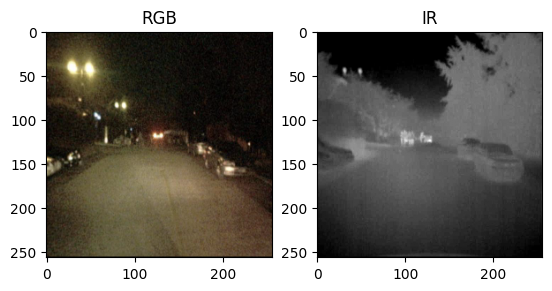

In [ ]:
import matplotlib.pyplot as plt

sample = torch.load("/content/Processed/visible/set03_V000_I00044.pt", weights_only=False)

rgb_tensor = sample['rgb']
ir_tensor = sample['ir']

unnorm_rgb = rgb_tensor * torch.tensor(RGB_STD).view(3,1,1) + torch.tensor(RGB_MEAN).view(3,1,1)
unnorm_rgb = unnorm_rgb.permute(1, 2, 0).numpy().clip(0, 1)

plt.subplot(1, 2, 1)
plt.imshow(unnorm_rgb)
plt.title("RGB")

plt.subplot(1, 2, 2)
plt.imshow(ir_tensor.squeeze(0), cmap='gray')
plt.title("IR")

plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        # RGB stream encoder
        self.rgb_enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2)
        )
        self.rgb_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        # IR stream encoder
        self.ir_enc1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, stride=2, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2)
        )
        self.ir_enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        # Dual-path attention fusion
        self.ir_attention = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 1, 1),
            nn.Sigmoid()
        )
        self.rgb_attention = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 1, 1),
            nn.Sigmoid()
        )

        # Dynamic feature modulation
        self.ir_modulation = nn.Sequential(
            nn.Conv2d(128, 128, 1),
            nn.Tanh()
        )

        # Decoder with enhanced skip connections
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2)
        )
        self.dec1_skip = nn.Conv2d(128, 128, 1)

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(64),
            nn.LeakyReLU(0.2)
        )

        self.dec3 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Tanh()
        )

        self.tone_adjust = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, rgb, ir):
        rgb_feat1 = self.rgb_enc1(rgb)
        rgb_feat2 = self.rgb_enc2(rgb_feat1)

        ir_feat1 = self.ir_enc1(ir)
        ir_feat2 = self.ir_enc2(ir_feat1)

        ir_attn = self.ir_attention(ir_feat2)
        rgb_attn = self.rgb_attention(rgb_feat2)
        ir_mod = self.ir_modulation(ir_feat2)

        fused = (rgb_feat2 * rgb_attn) + (ir_feat2 * (1 + ir_attn - rgb_attn)) * ir_mod

        d1 = self.dec1(fused)
        skip = self.dec1_skip(torch.cat([rgb_feat1, ir_feat1], dim=1))
        d1 = torch.cat([d1, skip], dim=1)

        d2 = self.dec2(d1)
        output = self.dec3(d2)
        output = self.tone_adjust(output)

        return output.clamp(-1, 1)

To run this next cell: Load fusion_model.pth from drive

In [ ]:
fusion_model = FusionModel().cuda()
fusion_model.load_state_dict(torch.load("/content/fusion_model.pth"))

<All keys matched successfully>

In [ ]:
import torch
import os
from tqdm import tqdm

processed_dir = "/content/Processed"
fused_output_dir = "/content/FusedImages"
visible_dir = "/content/Processed/visible"

os.makedirs(fused_output_dir, exist_ok=True)

# Load fusion model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
fusion_model.eval().to(DEVICE)

# Loop through all processed .pt files
for f in tqdm(sorted(os.listdir(visible_dir))):
    if not f.endswith(".pt"):
        continue

    path = os.path.join(visible_dir, f)
    data = torch.load(path, weights_only=False)

    rgb = data['rgb'].unsqueeze(0).to(DEVICE).float()
    ir = data['ir'].unsqueeze(0).to(DEVICE).float()

    with torch.no_grad():
        fused = fusion_model(rgb, ir)
        fused = (fused + 1) / 2

    torch.save({
        'fused': fused.squeeze(0).cpu(),
        'filename': data['filename']
    }, os.path.join(fused_output_dir, f))

100%|██████████| 6195/6195 [02:34<00:00, 40.17it/s]


In [ ]:
fused_dir = "/content/FusedImages"
fused_files = [f for f in os.listdir(fused_dir) if f.endswith(".pt")]
print(f"Total fused images: {len(fused_files)}")

Total fused images: 6195


In [ ]:
import torch
fused_sample = torch.load("/content/Fused_Images/set03_V000_I00044.pt",weights_only=False)
print(fused_sample["fused"].shape)
print(fused_sample["filename"])

torch.Size([3, 256, 256])
set03_V000_I00044.jpg


Visualizing Fused Image with Groundtruth

In [ ]:
import torch
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# File info
fused_path = "/content/Fused_Images/set03_V000_I00044.pt"
annotation_root = "/content/kaist_annotations/kaist-paired/annotations"
visible_img_root = "/content/kaist_organized/visible"

base_name = os.path.splitext(os.path.basename(fused_path))[0]
set_name, video_id, frame_id = base_name.split("_")

# Original annotation path
anno_path = os.path.join(annotation_root, set_name, video_id, "visible", frame_id + ".txt")

# Original image to get size
original_img_path = os.path.join(visible_img_root, base_name + ".jpg")

In [ ]:
# Get original size
with Image.open(original_img_path) as img:
    original_width, original_height = img.size

# Set fused size
TARGET_WIDTH = 256
TARGET_HEIGHT = 256

# Label map
LABEL_MAP = {'person': 0, 'people': 1, 'cyclist': 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

In [ ]:
annotations = []
with open(anno_path, 'r') as f:
    lines = [line.strip() for line in f if line.strip() and not line.startswith('%')]

for ann_id, line in enumerate(lines):
    parts = line.split()
    if len(parts) < 5:
        continue
    cls_name = parts[0]
    if cls_name not in LABEL_MAP:
        continue
    x_min, y_min, box_width, box_height = map(float, parts[1:5])

    # Resizing annotations to fused size to ensure alignment
    x_min = x_min * TARGET_WIDTH / original_width
    y_min = y_min * TARGET_HEIGHT / original_height
    box_width = box_width * TARGET_WIDTH / original_width
    box_height = box_height * TARGET_HEIGHT / original_height

    annotations.append({
        "bbox": [x_min, y_min, box_width, box_height],
        "category_id": LABEL_MAP[cls_name]
    })

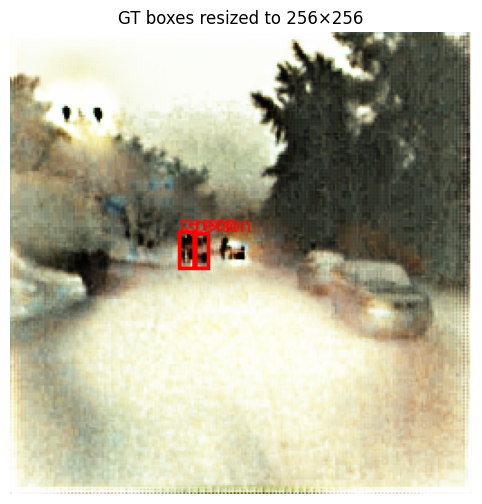

In [ ]:
# Load fused tensor
data = torch.load(fused_path)
fused_tensor = data['fused'].clamp(0, 1)  # [3, H, W]

# Convert to PIL
from torchvision.transforms.functional import to_pil_image
pil_image = to_pil_image(fused_tensor)

draw = ImageDraw.Draw(pil_image)
for ann in annotations:
    x, y, w, h = ann["bbox"]
    label = INV_LABEL_MAP[ann["category_id"]]
    draw.rectangle([x, y, x+w, y+h], outline="red", width=2)
    draw.text((x, y-10), label, fill="red")

plt.figure(figsize=(8, 6))
plt.imshow(pil_image)
plt.title("GT boxes resized to 256×256")
plt.axis("off")
plt.show()

In [ ]:
print("Min pixel value:", fused_tensor.min().item())
print("Max pixel value:", fused_tensor.max().item())

Min pixel value: 5.766749382019043e-05
Max pixel value: 0.999996542930603


In [ ]:
#Checking what the full dataset's std and mean is to replace in Deformable DETR's processor for normalization
import torch
import os
from tqdm import tqdm

fused_dir = "/content/FusedImages"

all_means = []
all_stds = []

for f in tqdm(os.listdir(fused_dir)):
    if not f.endswith(".pt"):
        continue
    data = torch.load(os.path.join(fused_dir, f))
    fused = data["fused"].clamp(0, 1)

    # Compute per-channel mean and std
    mean = fused.mean(dim=(1, 2))
    std = fused.std(dim=(1, 2))
    all_means.append(mean)
    all_stds.append(std)

# Stack and compute dataset-level stats
all_means = torch.stack(all_means)
all_stds = torch.stack(all_stds)

fused_mean = all_means.mean(dim=0)
fused_std = all_stds.mean(dim=0)

print(f"Fused image_mean: {fused_mean.tolist()}")
print(f"Fused image_std : {fused_std.tolist()}")

 56%|█████▌    | 3468/6195 [00:29<00:23, 117.52it/s]


KeyboardInterrupt: 

Removing original dataset after preprocessing to free some storage

In [ ]:
original_kaist_path = "/content/kaist_dataset"
shutil.rmtree(original_kaist_path)

In [ ]:
import os
import shutil
fused_dir = "/content/FusedImages"
annotation_root = "/content/kaist_annotations/kaist-paired/annotations"
output_dir = "/content/fused_split"
for split in ['train', 'val', 'test']:
    ann_dir = os.path.join(output_dir, split, 'annotations')
    img_dir = os.path.join(output_dir, split, 'images')
    shutil.rmtree(ann_dir, ignore_errors=True)
    shutil.rmtree(img_dir, ignore_errors=True)
    os.makedirs(ann_dir, exist_ok=True)
    os.makedirs(img_dir, exist_ok=True)

Train/Val/Test split including images and annotations

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

annotation_root = "/content/kaist_annotations/kaist-paired/annotations"
output_dir = "/content/fused_split"

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(output_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, split, 'annotations'), exist_ok=True)

# Step 1: Match .pt files with valid annotation files
def get_valid_pairs():
    pairs = []
    for f in os.listdir(fused_dir):
        if not f.endswith(".pt"):
            continue
        base = os.path.splitext(f)[0]
        try:
            set_name, video_id, frame_id = base.split("_")
        except ValueError:
            continue

        ann_path = os.path.join(annotation_root, set_name, video_id, "visible", frame_id + ".txt")
        img_path = os.path.join(fused_dir, f)

        if os.path.exists(ann_path):
            with open(ann_path, "r") as a:
                lines = [line for line in a if line.strip() and not line.startswith("%")]
            if len(lines) > 0:
                pairs.append((img_path, ann_path))
    return pairs

fused_pairs = get_valid_pairs()
print(f"Total valid fused samples with annotations: {len(fused_pairs)}")

train_val, test = train_test_split(fused_pairs, test_size=0.15, random_state=42)
train, val = train_test_split(train_val, test_size=0.176, random_state=42)

splits = {'train': train, 'val': val, 'test': test}

# Step 2: Copy images and annotations into structured folders
for split, items in splits.items():
    for img_path, ann_path in items:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        # Copy .pt file
        shutil.copy(img_path, os.path.join(output_dir, split, 'images', base_name + ".pt"))
        # Copy annotation as .txt and rename to match
        shutil.copy(ann_path, os.path.join(output_dir, split, 'annotations', base_name + ".txt"))

print("Finished splitting fused dataset into train/val/test.")

Total valid fused samples with annotations: 6195
Finished splitting fused dataset into train/val/test.


In [ ]:
original_kaist_path = "/content/kaist_annotations"
shutil.rmtree(original_kaist_path)

In [ ]:
LABEL_MAP = {
    "person": 0,
    "cyclist": 1,
    "people": 2
}

In [ ]:
DATA_DIR = {
    'train': {
        'images': '/content/fused_split/train/images',
        'annotations': '/content/fused_split/train/annotations'
    },
    'val': {
        'images': '/content/fused_split/val/images',
        'annotations': '/content/fused_split/val/annotations'
    },
    'test': {
        'images': '/content/fused_split/test/images',
        'annotations': '/content/fused_split/test/annotations'
    }
}

In [ ]:
print(os.listdir(DATA_DIR['train']['images'])[:5])
print(os.listdir(DATA_DIR['train']['annotations'])[:5])

['set04_V001_I01731.pt', 'set04_V000_I00839.pt', 'set04_V001_I01819.pt', 'set04_V000_I01396.pt', 'set03_V000_I03176.pt']
['set03_V001_I00971.txt', 'set03_V001_I00390.txt', 'set04_V000_I01319.txt', 'set03_V000_I01657.txt', 'set03_V001_I00192.txt']


In [ ]:
import os
import torch
from transformers import DeformableDetrForObjectDetection, DeformableDetrImageProcessor
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
from tqdm import tqdm
from torchvision import transforms
from torchvision.transforms import ToPILImage, ColorJitter
import torchvision.transforms.functional as F
import random
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "SenseTime/deformable-detr"
BATCH_SIZE = 4

# Label mapping
LABEL_MAP = {'person': 0, 'people': 1, 'cyclist': 2}

model = DeformableDetrForObjectDetection.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
).to(DEVICE)

# Deformable Detr's processor
processor = DeformableDetrImageProcessor.from_pretrained(
    MODEL_NAME,
    do_normalize=True,
    image_mean=[0.6919, 0.6678, 0.5422],
    image_std=[0.2389, 0.2457, 0.2339],
    size={"shortest_edge": 600, "longest_edge": 1333},
    do_resize=True
)

# Converting annotations to COCO json style for it to be compatible with Deformable DETR
def fusedanno_to_detr(txt_path, image_id, width, height, original_width, original_height):
    with open(txt_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.startswith('%')]

    annotations = []
    for ann_id, line in enumerate(lines):
        parts = line.split()
        if len(parts) < 5:
            continue
        cls_name = parts[0]
        if cls_name not in LABEL_MAP:
            continue
        x_min, y_min, box_width, box_height = map(float, parts[1:5])

        x_min = x_min * width / original_width
        y_min = y_min * height / original_height
        box_width = box_width * width / original_width
        box_height = box_height * height / original_height

        annotations.append({
            "id": ann_id,
            "bbox": [x_min, y_min, box_width, box_height],
            "area": box_width * box_height,
            "category_id": LABEL_MAP[cls_name],
            "iscrowd": 0,
            "image_id": image_id,
            "segmentation": []
        })

    return {
        "image_id": image_id,
        "annotations": annotations,
        "width": width,
        "height": height,
        "orig_size": (height, width)
    }

class FusedDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, processor):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.processor = processor
        self.image_files = []
        for f in sorted(os.listdir(image_dir)):
            if f.endswith('.pt'):
                base = os.path.splitext(f)[0]
                ann_path = os.path.join(annotation_dir, base + ".txt")
                if os.path.exists(ann_path):
                    with open(ann_path, 'r') as a:
                        lines = [line for line in a if line.strip() and not line.startswith('%')]
                    if len(lines) > 0:
                        self.image_files.append(f)
        self.color_jitter = ColorJitter(brightness=0.3, contrast=0.3)
        self.blur = transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))
        print(f"Loaded {len(self.image_files)} valid fused .pt files with annotations.")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        fused_path = os.path.join(self.image_dir, self.image_files[idx])
        data = torch.load(fused_path)
        fused_tensor = data['fused']
        filename = data['filename']
        base_name = os.path.splitext(filename)[0]
        height, width = fused_tensor.shape[1:]

        original_img_path = os.path.join("/content/kaist_organized/visible", base_name + ".jpg")
        with Image.open(original_img_path) as img:
            original_width, original_height = img.size

        # Convert tensor to PIL image
        pil_image = ToPILImage()(fused_tensor.clamp(0, 1))

        # Augmentation
        if random.random() < 0.3:
            pil_image = self.blur(pil_image)

        pil_image = self.color_jitter(pil_image)

        annotation_path = os.path.join(self.annotation_dir, base_name + ".txt")
        target = fusedanno_to_detr(annotation_path, idx, width, height, original_width=original_width, original_height=original_height)

        # Processor
        processed = self.processor(
            images=pil_image,
            annotations=target,
            return_tensors="pt"
        )

        return {
            "pixel_values": processed["pixel_values"].squeeze(0).float(),
            "pixel_mask": processed["pixel_mask"].squeeze(0).float(),
            "labels": processed["labels"][0]
        }

def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    pixel_mask = torch.stack([item["pixel_mask"] for item in batch])
    labels = [item["labels"] for item in batch]
    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "labels": labels
    }

def create_dataloaders():
    train_dataset = FusedDataset(
        DATA_DIR['train']['images'],
        DATA_DIR['train']['annotations'],
        processor
    )
    val_dataset = FusedDataset(
        DATA_DIR['val']['images'],
        DATA_DIR['val']['annotations'],
        processor
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    return train_loader, val_loader

train_loader, val_loader = create_dataloaders()

Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DeformableDetrForObjectDetection wer

Loaded 4338 valid fused .pt files with annotations.
Loaded 927 valid fused .pt files with annotations.


Checking before inputting to DETR

In [ ]:
batch = next(iter(train_loader))
print("Pixel values range:", batch["pixel_values"].min(), batch["pixel_values"].max())  # Should be ~[-1, 1]
print("Sample label:", batch["labels"][0])  # Check bbox values are normalized

Pixel values range: tensor(-2.8962) tensor(1.9572)
Sample label: {'size': tensor([600, 600]), 'image_id': tensor([3339]), 'class_labels': tensor([0, 0]), 'boxes': tensor([[0.7852, 0.4219, 0.0359, 0.0898],
        [0.7469, 0.4170, 0.0312, 0.0879]]), 'area': tensor([1162.3535,  988.7695]), 'iscrowd': tensor([0, 0]), 'orig_size': tensor([256, 256])}


My Training Loop

In [ ]:
from torch.cuda.amp import autocast, GradScaler
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers import get_scheduler

# Phase-aware optimizer builder
#Different LR's for different layers
def get_param_groups(model, phase):
    groups = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if "model.backbone.conv_encoder.model.layer3" in name:
            lr = 5e-6 if phase >= 2 else None
        elif "model.encoder" in name:
            lr = 2e-5 if phase >= 2 else None
        elif "model.backbone.conv_encoder.model.layer4" in name:
            lr = 1e-5
        elif "decoder" in name:
            lr = 3e-5
        elif "class_embed" in name or "bbox_embed" in name:
            lr = 3e-5
        else:
            lr = 2e-5

        if lr is not None:
            groups.append({"params": [param], "lr": lr})

    return groups

# Gradual unfreezing
def apply_unfreeze(model, phase):
    UNFREEZE_KEYS = [
        "class_embed",
        "bbox_embed",
        "model.decoder",
        "model.input_proj",
        "model.backbone.conv_encoder.model.layer4"
    ]
    if phase >= 2:
        UNFREEZE_KEYS += [
            "model.encoder",
            "model.backbone.conv_encoder.model.layer3"
        ]

    for name, param in model.named_parameters():
        param.requires_grad = any(k in name for k in UNFREEZE_KEYS)

# for converting groundtruth from normalized to absolute to evaluate
def cxcywh_to_xyxy(boxes, size):
    h, w = size
    boxes = boxes.clone()
    cx, cy, bw, bh = boxes.unbind(-1)
    x1 = (cx - bw / 2) * w
    y1 = (cy - bh / 2) * h
    x2 = (cx + bw / 2) * w
    y2 = (cy + bh / 2) * h
    return torch.stack([x1, y1, x2, y2], dim=-1)


# Training loop with phase control

def train_detr(model, train_loader, val_loader, processor, num_epochs, save_path):
    phase = 1
    apply_unfreeze(model, phase)
    optimizer = AdamW(get_param_groups(model, phase), weight_decay=1e-4)

    scaler = GradScaler()
    metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])
    scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=100,
                               num_training_steps=num_epochs * len(train_loader))

    best_val_loss = float('inf')
    no_improve = 0
    patience = 6
    min_epochs = 10

    for epoch in range(num_epochs):
        model.train()
        epoch_stats = {"total": 0.0, "class": 0.0, "bbox": 0.0, "giou": 0.0}

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            pixel_values = batch["pixel_values"].to(DEVICE)
            pixel_mask = batch["pixel_mask"].to(DEVICE)
            labels = batch["labels"]

            targets = [{
                "class_labels": l["class_labels"].to(DEVICE),
                "boxes": l["boxes"].to(DEVICE)
            } for l in labels]

            optimizer.zero_grad()
            with autocast():
                outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            epoch_stats["total"] += loss.item()
            loss_name_map = {
                "loss_ce": "class",
                "loss_bbox": "bbox",
                "loss_giou": "giou"
            }
            for k, v in outputs.loss_dict.items():
                if k in loss_name_map:
                    epoch_stats[loss_name_map[k]] += v.item()

        avg_train_loss = epoch_stats["total"] / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        metric.reset()
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                pixel_values = batch["pixel_values"].to(DEVICE)
                pixel_mask = batch["pixel_mask"].to(DEVICE)
                labels = batch["labels"]
                targets = [{
                    "class_labels": l["class_labels"].to(DEVICE),
                    "boxes": l["boxes"].to(DEVICE)
                } for l in labels]

                with autocast():
                    outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=targets)
                val_loss += outputs.loss.item()

                orig_sizes = [l["orig_size"] for l in labels]
                results = processor.post_process_object_detection(outputs, target_sizes=orig_sizes, threshold=0.1)

                preds = [{
                    "boxes": r["boxes"].cpu(),
                    "scores": r["scores"].cpu(),
                    "labels": r["labels"].cpu()
                } for r in results]

                gts = []
                for l in labels:
                    size = l["orig_size"]
                    boxes = cxcywh_to_xyxy(l["boxes"].cpu(), size)
                    gts.append({
                        "boxes": boxes,
                        "labels": l["class_labels"].cpu()
                    })

                metric.update(preds, gts)

        avg_val_loss = val_loss / len(val_loader)
        metrics = metric.compute()

        print(f"\nEpoch {epoch+1} Summary:")
        print(f"Train Loss: {avg_train_loss:.4f} | Cls: {epoch_stats['class']:.2f} | BBox: {epoch_stats['bbox']:.2f} | GIoU: {epoch_stats['giou']:.2f}")
        print(f"Val Loss: {avg_val_loss:.4f} | mAP@0.5: {metrics['map_50']:.4f}")

        # Early stopping and saving
        if epoch >= min_epochs:
            if avg_val_loss < best_val_loss * 0.995:
                best_val_loss = avg_val_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': avg_val_loss,
                    'map_50': metrics['map_50'].item()
                }, save_path)
                no_improve = 0
                print(f"Saved best model (Val Loss: {avg_val_loss:.4f}, mAP@0.5: {metrics['map_50']:.4f})")
            else:
                no_improve += 1
                print(f"▁ No improvement ({no_improve}/{6})")
                if no_improve >= 6:
                    print("Early stopping triggered.")
                    break

        # Phase shift (after epoch 6)
        if epoch == 6:
            phase = 2
            print("\nEntering Phase 2: Unfreezing encoder + layer3")
            apply_unfreeze(model, phase)
            optimizer = AdamW(get_param_groups(model, phase), weight_decay=1e-4)
            scheduler = get_scheduler("cosine", optimizer=optimizer, num_warmup_steps=50,
                                      num_training_steps=(num_epochs - epoch) * len(train_loader))

In [ ]:
save_path="/content/Finetuned_Fused.pth"

In [ ]:
train_detr(model, train_loader, val_loader, processor, num_epochs=30, save_path=save_path)

<ipython-input-14-cde6d8c81469>:68: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1 Training:   0%|          | 0/1085 [00:00<?, ?it/s]<ipython-input-14-cde6d8c81469>:93: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation:   0%|          | 0/232 [00:00<?, ?it/s]<ipython-input-14-cde6d8c81469>:130: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 232/232 [01:45<00:00,  2.19it/s]



Epoch 1 Summary:
Train Loss: 3.7762 | Cls: 3276.79 | BBox: 36.55 | GIoU: 318.80
Val Loss: 0.9934 | mAP@0.5: 0.2795


Validation: 100%|██████████| 232/232 [01:45<00:00,  2.21it/s]



Epoch 2 Summary:
Train Loss: 0.9072 | Cls: 301.93 | BBox: 28.96 | GIoU: 268.78
Val Loss: 0.8784 | mAP@0.5: 0.4823


Validation: 100%|██████████| 232/232 [01:38<00:00,  2.36it/s]


...


Epoch 15 Summary:
Train Loss: 0.4575 | Cls: 61.44 | BBox: 16.51 | GIoU: 176.19
Val Loss: 0.4822 | mAP@0.5: 0.9203
Saved best model (Val Loss: 0.4822, mAP@0.5: 0.9203)


Validation: 100%|██████████| 232/232 [01:38<00:00,  2.36it/s]



Epoch 16 Summary:
Train Loss: 0.4408 | Cls: 57.13 | BBox: 15.92 | GIoU: 170.74
Val Loss: 0.4598 | mAP@0.5: 0.9232
Saved best model (Val Loss: 0.4598, mAP@0.5: 0.9232)


Epoch 17 Training:  52%|█████▏    | 562/1085 [08:04<07:30,  1.16it/s]


KeyboardInterrupt: 

To run next cell: Load Finetuned_Fused.pth from drive for evaluation

In [ ]:
import torch
from transformers import DeformableDetrForObjectDetection, DeformableDetrImageProcessor

checkpoint_path = "/content/Finetuned_Fused.pth"

model = DeformableDetrForObjectDetection.from_pretrained("SenseTime/deformable-detr", num_labels=3, ignore_mismatched_sizes=True)

processor = DeformableDetrImageProcessor.from_pretrained(
    "SenseTime/deformable-detr",
    do_normalize=True,
    image_mean=[0.6919, 0.6678, 0.5422],
    image_std=[0.2389, 0.2457, 0.2339],
    size={"shortest_edge": 600, "longest_edge": 1333},
    do_resize=True
)

checkpoint = torch.load(checkpoint_path, map_location="cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval().to("cuda" if torch.cuda.is_available() else "cpu")

Some weights of the model checkpoint at SenseTime/deformable-detr were not used when initializing DeformableDetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DeformableDetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DeformableDetrForObjectDetection wer

DeformableDetrForObjectDetection(
  (model): DeformableDetrModel(
    (backbone): DeformableDetrConvModel(
      (conv_encoder): DeformableDetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DeformableDetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DeformableDetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DeformableDetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3):

In [ ]:
test_dataset = FusedDataset(
    DATA_DIR['test']['images'],
    DATA_DIR['test']['annotations'],
    processor
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

Loaded 930 valid fused .pt files with annotations.


In [ ]:
import os
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
from PIL import ImageDraw

# Example fused image
fused_test_img = "/content/fused_split/test/images/set03_V000_I00138.pt"
data = torch.load(fused_test_img)
fused_tensor = data['fused'].clamp(0, 1)
pil_image = to_pil_image(fused_tensor)
width, height = pil_image.size

In [ ]:
# Preprocess for model
inputs = processor(images=pil_image, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(**inputs)

processed = processor(images=pil_image, return_tensors="pt")

results = processor.post_process_object_detection(
    outputs,
    target_sizes=torch.tensor([(height, width)]),
    threshold=0.5
)[0]

In [ ]:
print("Image size (PIL):", pil_image.size)  # should be (256, 256)
print("Box coords before postprocessing:", outputs.pred_boxes[0][:3])
print("Box coords after postprocessing:", results["boxes"][:3])

Image size (PIL): (256, 256)
Box coords before postprocessing: tensor([[0.8910, 0.2294, 0.1139, 0.2702],
        [0.3545, 0.4556, 0.2269, 0.2634],
        [0.4720, 0.6483, 0.3464, 0.3403]], device='cuda:0')
Box coords after postprocessing: tensor([], device='cuda:0', size=(0, 4))


In [ ]:
import torch
from torchvision.transforms.functional import to_pil_image
from PIL import ImageDraw, ImageFont
import matplotlib.pyplot as plt

LABEL_ID_TO_NAME = {0: "person", 1: "people", 2: "cyclist"}

def visualize_predictions_with_ground_truth(model, processor, pt_path, txt_path, score_thresh=0.3):
    # Load image tensor
    data = torch.load(pt_path)
    fused_tensor = data['fused'].clamp(0, 1)
    pil_image = to_pil_image(fused_tensor)
    width, height = pil_image.size

    # Get predictions
    inputs = processor(images=pil_image, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)

    # Postprocess
    results = processor.post_process_object_detection(
        outputs,
        target_sizes=torch.tensor([(height, width)]).to(model.device),
        threshold=score_thresh
    )[0]

    # Prepare drawing
    draw = ImageDraw.Draw(pil_image)

    # Draw predicted boxes (red)
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        x1, y1, x2, y2 = box.tolist()
        label_name = LABEL_ID_TO_NAME.get(label.item(), str(label.item()))
        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)
        draw.text((x1, y1 - 10), f"{label_name} | {score:.2f}", fill="red")

    # Draw GT boxes (green)
    with open(txt_path, 'r') as f:
        for line in f:
            if not line.strip() or line.startswith("%"):
                continue
            parts = line.strip().split()
            if parts[0] not in LABEL_ID_TO_NAME:
                continue
            cls_name = parts[0]
            x, y, w, h = map(float, parts[1:5])
            draw.rectangle([x, y, x + w, y + h], outline="green", width=2)
            draw.text((x, y - 10), cls_name, fill="green")

    # Show
    plt.figure(figsize=(8, 8))
    plt.imshow(pil_image)
    plt.axis("off")
    plt.title("Ground Truth (Green) + Predicted Boxes (Red)")
    plt.show()

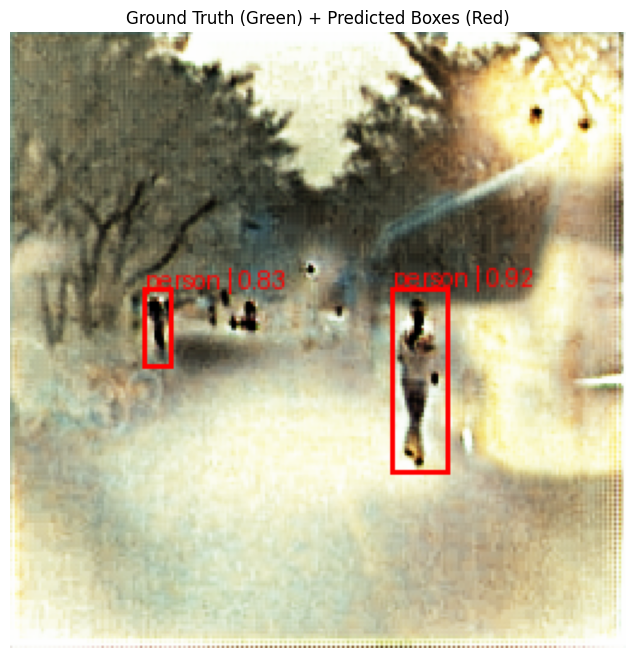

In [ ]:
pt_path = "/content/fused_split/test/images/set03_V000_I01012.pt"
txt_path = "/content/fused_split/test/annotations/set03_V000_I01012.txt"

visualize_predictions_with_ground_truth(model, processor, pt_path, txt_path)

In [ ]:
import torch
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import matplotlib.pyplot as plt
from PIL import ImageDraw
from torchvision.transforms.functional import to_pil_image

def cxcywh_to_xyxy(boxes, size):
    h, w = size
    boxes = boxes.clone()
    cx, cy, bw, bh = boxes.unbind(-1)
    x1 = (cx - bw / 2) * w
    y1 = (cy - bh / 2) * h
    x2 = (cx + bw / 2) * w
    y2 = (cy + bh / 2) * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

# Load model
checkpoint = torch.load("/content/Finetuned_Fused.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval().to(DEVICE)

metric = MeanAveragePrecision(iou_type="bbox", iou_thresholds=[0.5])
metric.to(DEVICE)

# Evaluation loop
with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_loader, desc="Evaluating")):
        pixel_values = batch["pixel_values"].to(DEVICE)
        pixel_mask = batch["pixel_mask"].to(DEVICE)
        labels = batch["labels"]

        outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

        orig_sizes = [l["orig_size"] for l in labels]
        target_sizes = torch.stack([torch.tensor(s) for s in orig_sizes]).to(DEVICE)

        results = processor.post_process_object_detection(
            outputs=outputs,
            target_sizes=target_sizes,
            threshold=0.1
        )

        # Predictions
        preds = [{
            "boxes": r["boxes"].cpu(),
            "scores": r["scores"].cpu(),
            "labels": r["labels"].cpu()
        } for r in results]

        # Ground truth
        gts = [{
            "boxes": cxcywh_to_xyxy(l["boxes"].cpu(), l["orig_size"]),
            "labels": l["class_labels"].cpu()
        } for l in labels]

        metric.update(preds, gts)

        # Visualize just the first batch
        if batch_idx == 0:
            for i in range(len(labels)):
                fused = batch["pixel_values"][i].cpu()
                img = to_pil_image(fused * torch.tensor([0.2389, 0.2457, 0.2339]).view(3,1,1) + torch.tensor([0.6919, 0.6678, 0.5422]).view(3,1,1))
                draw = ImageDraw.Draw(img)

                # Resize GT boxes to match fused_tensor size
                original_img_path = os.path.join("/content/kaist_organized/visible", os.path.basename(txt_path).replace(".txt", ".jpg"))
                with Image.open(original_img_path) as img:
                    orig_w, orig_h = img.size

                    scale_w = width / orig_w
                    scale_h = height / orig_h

                    with open(txt_path, 'r') as f:
                      for line in f:
                          if not line.strip() or line.startswith("%"):
                                continue
                      parts = line.strip().split()
                      if parts[0] not in LABEL_ID_TO_NAME:
                          continue
                      cls_name = parts[0]
                      x, y, w, h = map(float, parts[1:5])

                        # Rescale to match fused image size
                      x *= scale_w
                      y *= scale_h
                      w *= scale_w
                      h *= scale_h

                    draw.rectangle([x, y, x + w, y + h], outline="green", width=2)
                    draw.text((x, y - 10), cls_name, fill="green")


                # Predicted boxes (red)
                pred_boxes = preds[i]["boxes"]
                scores = preds[i]["scores"]
                for box, score in zip(pred_boxes, scores):
                    if score > 0.3:
                        x1, y1, x2, y2 = box
                        draw.rectangle([x1, y1, x2, y2], outline="red", width=2)

                plt.figure(figsize=(8, 6))
                plt.imshow(img)
                plt.title(f"Predictions (Red) vs Ground Truth (Green)")
                plt.axis("off")
                plt.show()

# Results
final_metrics = metric.compute()
print("\nEvaluation Results on Fused Test Set:")
print(f"mAP@0.5: {final_metrics['map_50']:.4f}")

Evaluating:   0%|          | 0/930 [00:00<?, ?it/s]<ipython-input-61-b265e1009d14>:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target_sizes = torch.stack([torch.tensor(s) for s in orig_sizes]).to(DEVICE)
Evaluating: 100%|██████████| 930/930 [02:13<00:00,  6.97it/s]



Evaluation Results on Fused Test Set:
mAP@0.5: 0.9088
